In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Auto-detect project root (multi-account compatible)
possible_paths = [
    '/content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels',
    '/content/drive/MyDrive/Road-Damage-Severity-Levels'
]

PROJECT_ROOT = None
for path in possible_paths:
    if os.path.exists(path):
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Project root not found. Ensure folder 'Road-Damage-Severity-Levels' "
        "is accessible in Google Drive."
    )

os.chdir(PROJECT_ROOT)

print("Project root detected:")
print(f"  {PROJECT_ROOT}")
print(f"\nWorking directory: {os.getcwd()}")

Mounted at /content/drive
Project root detected:
  /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels

Working directory: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels


In [2]:
!pip install -q ultralytics tensorflow pillow opencv-python scikit-learn matplotlib seaborn pandas

print("Dependencies installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.1 MB/s eta 0:00:00
Dependencies installed successfully


In [3]:
import json
import shutil

def safe_makedirs(path):
    os.makedirs(path, exist_ok=True)
    return path

# Input paths (Google Drive)
YOLO_MODEL_PATH = os.path.join(PROJECT_ROOT, '4_yolo_models', 'yolov8_best.pt')
CNN_MODEL_PATH = os.path.join(PROJECT_ROOT, '5_cnn_models', '3_model', 'severity_classifier3_best.weights.h5')
SEVERITY_THRESHOLDS_PATH = os.path.join(PROJECT_ROOT, '1_analysis_results', 'severity_thresholds.json')
DATASET_ZIP_PATH = os.path.join(PROJECT_ROOT, 'dataset.zip')

# Output paths
INFERENCE_RESULTS_DIR = safe_makedirs(os.path.join(PROJECT_ROOT, 'inference_results'))
VISUALIZATIONS_DIR = safe_makedirs(os.path.join(INFERENCE_RESULTS_DIR, 'visualizations'))
METRICS_DIR = safe_makedirs(os.path.join(INFERENCE_RESULTS_DIR, 'metrics'))

# Local SSD paths (for faster processing)
DATASET_LOCAL = '/content/dataset'
YOLO_MODEL_LOCAL = '/content/yolov8_best.pt'
CNN_MODEL_LOCAL = '/content/severity_classifier3_best.weights.h5'

print("Path configuration:")
print(f"  YOLO model (Drive): {YOLO_MODEL_PATH}")
print(f"  CNN model (Drive): {CNN_MODEL_PATH}")
print(f"  Thresholds: {SEVERITY_THRESHOLDS_PATH}")
print(f"  Dataset ZIP: {DATASET_ZIP_PATH}")
print(f"  Output: {INFERENCE_RESULTS_DIR}")

# Verify critical files exist
critical_files = {
    'YOLO model': YOLO_MODEL_PATH,
    'CNN model': CNN_MODEL_PATH,
    'Severity thresholds': SEVERITY_THRESHOLDS_PATH,
    'Dataset ZIP': DATASET_ZIP_PATH
}

print("\nVerifying critical files:")
all_exist = True
for name, path in critical_files.items():
    exists = os.path.exists(path)
    status = "OK" if exists else "MISSING"
    print(f"  [{status}] {name}")
    if not exists:
        all_exist = False

if not all_exist:
    raise FileNotFoundError("Some critical files are missing. Check paths above.")

print("\nAll critical files verified successfully")

Path configuration:
  YOLO model (Drive): /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/4_yolo_models/yolov8_best.pt
  CNN model (Drive): /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/5_cnn_models/3_model/severity_classifier3_best.weights.h5
  Thresholds: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/1_analysis_results/severity_thresholds.json
  Dataset ZIP: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/dataset.zip
  Output: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/inference_results

Verifying critical files:
  [OK] YOLO model
  [OK] CNN model
  [OK] Severity thresholds
  [OK] Dataset ZIP

All critical files verified successfully


In [6]:
import zipfile
from pathlib import Path
import os

print("Extracting dataset to local SSD...")
print(f"  Source: {DATASET_ZIP_PATH}")
print(f"  Destination: {DATASET_LOCAL}")

os.makedirs(DATASET_LOCAL, exist_ok=True)

with zipfile.ZipFile(DATASET_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(DATASET_LOCAL)

# Verify extraction
test_images_dir = os.path.join(DATASET_LOCAL, 'test', 'images')
test_labels_dir = os.path.join(DATASET_LOCAL, 'test', 'labels')

if not os.path.exists(test_images_dir):
    print(f"Warning: test/images tidak ditemukan. Mengecek folder test/ langsung...")
    test_images_dir = os.path.join(DATASET_LOCAL, 'test')

    if not os.path.exists(test_images_dir):
        raise FileNotFoundError(f"Test images benar-benar tidak ditemukan di: {DATASET_LOCAL}")

# Count test samples
test_images = list(Path(test_images_dir).glob('*.jpg'))
print(f"\nExtraction completed")
print(f"  Test images found: {len(test_images)}")

Extracting dataset to local SSD...
  Source: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/dataset.zip
  Destination: /content/dataset

Extraction completed
  Test images found: 5758


In [7]:
print("Copying models to local SSD for faster inference...")

# Copy YOLO model
shutil.copy2(YOLO_MODEL_PATH, YOLO_MODEL_LOCAL)
print(f"  YOLO model copied: {YOLO_MODEL_LOCAL}")

# Copy CNN model
shutil.copy2(CNN_MODEL_PATH, CNN_MODEL_LOCAL)
print(f"  CNN model copied: {CNN_MODEL_LOCAL}")

print("\nModels ready for inference")

Copying models to local SSD for faster inference...
  YOLO model copied: /content/yolov8_best.pt
  CNN model copied: /content/severity_classifier3_best.weights.h5

Models ready for inference


In [8]:
from ultralytics import YOLO

print("Loading YOLO model...")
yolo_model = YOLO(YOLO_MODEL_LOCAL)

print(f"YOLO model loaded successfully")
print(f"  Model: YOLOv8m")
print(f"  Task: Road damage detection")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading YOLO model...
YOLO model loaded successfully
  Model: YOLOv8m
  Task: Road damage detection


In [9]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

def build_cnn_model():
    """
    Rebuild CNN architecture (must match training architecture)
    """
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.3)(x)
    outputs = Dense(3, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model

print("Building CNN model architecture...")
cnn_model = build_cnn_model()

print("Loading CNN weights...")
cnn_model.load_weights(CNN_MODEL_LOCAL)

print("CNN model loaded successfully")
print(f"  Architecture: MobileNetV2 + Custom Head")
print(f"  Classes: Rendah (0), Sedang (1), Tinggi (2)")

Building CNN model architecture...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loading CNN weights...
CNN model loaded successfully
  Architecture: MobileNetV2 + Custom Head
  Classes: Rendah (0), Sedang (1), Tinggi (2)


In [10]:
import json

# Load severity thresholds
with open(SEVERITY_THRESHOLDS_PATH, 'r') as f:
    severity_thresholds = json.load(f)

print("Severity thresholds loaded:")
for class_id, vals in severity_thresholds.items():
    print(f"  Class {class_id}: low={vals['low_threshold']:.4f}, high={vals['high_threshold']:.4f}")

# Define class mappings
DAMAGE_CLASSES = {
    0: 'Longitudinal Crack',
    1: 'Transverse Crack',
    2: 'Alligator Crack',
    4: 'Pothole'
}

SEVERITY_CLASSES = {
    0: 'Rendah',
    1: 'Sedang',
    2: 'Tinggi'
}

SEVERITY_COLORS = {
    0: (0, 255, 0),    # Green for Rendah
    1: (0, 165, 255),  # Orange for Sedang
    2: (0, 0, 255)     # Red for Tinggi
}

print("\nClass mappings configured")

Severity thresholds loaded:
  Class 0: low=0.0500, high=0.1500
  Class 1: low=0.0500, high=0.1500
  Class 2: low=0.0500, high=0.1500
  Class 4: low=0.0500, high=0.1500

Class mappings configured


In [11]:
import cv2
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def run_integrated_pipeline(image_path, yolo_model, cnn_model, conf_threshold=0.25):
    """
    Run integrated YOLO detection + CNN severity classification

    Returns:
        results: dict with detections and severity predictions
    """
    # Read image
    img = cv2.imread(str(image_path))
    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Step 1: YOLO Detection
    yolo_results = yolo_model.predict(str(image_path), conf=conf_threshold, verbose=False)

    if len(yolo_results) == 0 or len(yolo_results[0].boxes) == 0:
        return {
            'image_path': str(image_path),
            'image_shape': (h, w),
            'detections': [],
            'num_detections': 0
        }

    boxes = yolo_results[0].boxes.cpu().numpy()

    # Step 2: Process each detection
    detections = []

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.xyxy[0].astype(int)
        conf = float(box.conf[0])
        cls = int(box.cls[0])

        # Ensure valid crop region
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        if x2 <= x1 or y2 <= y1:
            continue

        # Extract crop
        crop = img_rgb[y1:y2, x1:x2]

        # Resize and preprocess for CNN
        crop_resized = cv2.resize(crop, (224, 224))
        crop_preprocessed = preprocess_input(crop_resized)
        crop_batch = np.expand_dims(crop_preprocessed, axis=0)

        # Step 3: CNN Severity Classification
        severity_probs = cnn_model.predict(crop_batch, verbose=0)[0]
        severity_class = int(np.argmax(severity_probs))
        severity_confidence = float(severity_probs[severity_class])

        detection = {
            'bbox': [int(x1), int(y1), int(x2), int(y2)],
            'detection_conf': conf,
            'damage_class': cls,
            'damage_name': DAMAGE_CLASSES.get(cls, f'Class {cls}'),
            'severity_class': severity_class,
            'severity_name': SEVERITY_CLASSES[severity_class],
            'severity_confidence': severity_confidence,
            'severity_probs': severity_probs.tolist()
        }

        detections.append(detection)

    return {
        'image_path': str(image_path),
        'image_shape': (h, w),
        'detections': detections,
        'num_detections': len(detections)
    }

print("Integrated inference pipeline function defined")
print("  Input: Image path")
print("  Process: YOLO detection → Crop → CNN classification")
print("  Output: Detection boxes + Severity predictions")

Integrated inference pipeline function defined
  Input: Image path
  Process: YOLO detection → Crop → CNN classification
  Output: Detection boxes + Severity predictions


In [12]:
from tqdm import tqdm
import json

print("Running inference on test set...")
print(f"  Total test images: {len(test_images)}")

all_results = []

for img_path in tqdm(test_images, desc="Processing images"):
    result = run_integrated_pipeline(img_path, yolo_model, cnn_model, conf_threshold=0.25)

    if result is not None:
        all_results.append(result)

print(f"\nInference completed")
print(f"  Processed images: {len(all_results)}")

# Calculate statistics
total_detections = sum([r['num_detections'] for r in all_results])
images_with_detections = sum([1 for r in all_results if r['num_detections'] > 0])

print(f"  Images with detections: {images_with_detections}/{len(all_results)}")
print(f"  Total detections: {total_detections}")

# Save raw inference results
inference_results_path = os.path.join(METRICS_DIR, 'inference_results.json')
with open(inference_results_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"\nInference results saved: {inference_results_path}")

Running inference on test set...
  Total test images: 5758


Processing images: 100%|██████████| 5758/5758 [19:09<00:00,  5.01it/s]



Inference completed
  Processed images: 5757
  Images with detections: 3729/5757
  Total detections: 7875

Inference results saved: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/inference_results/metrics/inference_results.json


In [13]:
def load_ground_truth_labels(image_path, dataset_local):
    """
    Load ground truth detection and severity labels
    """
    img_name = Path(image_path).stem

    # Detection labels (YOLO format)
    label_path = os.path.join(dataset_local, 'test', 'labels', f"{img_name}.txt")
    detections_gt = []

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls = int(parts[0])
                    # YOLO format: class x_center y_center width height (normalized)
                    detections_gt.append({
                        'class': cls,
                        'bbox_norm': [float(x) for x in parts[1:5]]
                    })

    # Severity labels
    severity_path = os.path.join(dataset_local, 'test', 'severity', f"{img_name}.json")
    severities_gt = []

    if os.path.exists(severity_path):
        with open(severity_path, 'r') as f:
            sev_data = json.load(f)
            severities_gt = [ann['severity'] for ann in sev_data.get('annotations', [])]

    return {
        'detections': detections_gt,
        'severities': severities_gt
    }

print("Ground truth loading function defined")

Ground truth loading function defined


In [15]:
import json
import os
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, average_precision_score

print("Evaluating YOLO detection performance...")

# Run YOLO validation on test set
test_data_yaml_content = f"""
path: {DATASET_LOCAL}
train: train/images
val: val/images
test: test/images

nc: 4
names: {list(DAMAGE_CLASSES.values())}
"""

# Create temporary data.yaml for YOLO validation
temp_yaml_path = '/content/temp_test_data.yaml'
with open(temp_yaml_path, 'w') as f:
    f.write(test_data_yaml_content)

# Run YOLO validation
yolo_metrics = yolo_model.val(data=temp_yaml_path, split='test', verbose=False)

precision_val = np.mean(yolo_metrics.box.p)
recall_val = np.mean(yolo_metrics.box.r)

print("\nYOLO Detection Metrics:")
print(f"  mAP@0.5: {yolo_metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95: {yolo_metrics.box.map:.4f}")
print(f"  Precision: {precision_val:.4f}")
print(f"  Recall: {recall_val:.4f}")

# Per-class metrics
print("\nPer-class Detection Performance:")
for i, class_name in DAMAGE_CLASSES.items():
    class_indices = list(yolo_metrics.box.ap_class_index)
    if i in class_indices:
        idx = class_indices.index(i)
        ap50 = yolo_metrics.box.ap50[idx]
        print(f"  {class_name}: AP@0.5 = {ap50:.4f}")

# Save detection metrics
detection_metrics = {
    'mAP@0.5': float(yolo_metrics.box.map50),
    'mAP@0.5:0.95': float(yolo_metrics.box.map),
    'precision': float(precision_val),
    'recall': float(recall_val)
}

os.makedirs(METRICS_DIR, exist_ok=True)

with open(os.path.join(METRICS_DIR, 'yolo_detection_metrics.json'), 'w') as f:
    json.dump(detection_metrics, f, indent=2)

print("\nDetection metrics saved")

Evaluating YOLO detection performance...
Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1690.0±487.2 MB/s, size: 72.7 KB)
val: Scanning /content/dataset/test/labels.cache... 5757 images, 2215 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 5758/5758 1.0Git/s 0.0s
val: /content/dataset/test/images/Japan_006457.jpg: ignoring corrupt image/label: cannot identify image file '/content/dataset/test/images/Japan_006457.jpg'
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 2.1it/s 2:54
                   all       5757       8086      0.581      0.505       0.53       0.26
Speed: 1.1ms preprocess, 21.0ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/runs/detect/val2

YOLO Detection Metrics:
  mAP@0.5: 0.5304
  mAP@0.5:0.95: 0.2604
  Precision: 0.5808
  Recall: 0.5

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("Evaluating CNN severity classification on detected crops...")

# Collect all severity predictions and ground truths
y_true_severity = []
y_pred_severity = []

for result in tqdm(all_results, desc="Matching predictions with ground truth"):
    img_path = result['image_path']
    gt_labels = load_ground_truth_labels(img_path, DATASET_LOCAL)

    # Match detections with ground truth severities
    for i, detection in enumerate(result['detections']):
        if i < len(gt_labels['severities']):
            y_true_severity.append(gt_labels['severities'][i])
            y_pred_severity.append(detection['severity_class'])

if len(y_true_severity) == 0:
    print("Warning: No ground truth severities found for evaluation")
else:
    # Classification report
    print("\nSeverity Classification Report:")
    print(classification_report(
        y_true_severity,
        y_pred_severity,
        target_names=list(SEVERITY_CLASSES.values()),
        digits=4
    ))

    # Confusion matrix
    cm = confusion_matrix(y_true_severity, y_pred_severity)
    cm_df = pd.DataFrame(
        cm,
        index=list(SEVERITY_CLASSES.values()),
        columns=list(SEVERITY_CLASSES.values())
    )

    print("\nConfusion Matrix:")
    print(cm_df)

    # Save severity metrics
    severity_metrics = {
        'classification_report': classification_report(
            y_true_severity,
            y_pred_severity,
            target_names=list(SEVERITY_CLASSES.values()),
            output_dict=True
        ),
        'confusion_matrix': cm.tolist(),
        'total_samples': len(y_true_severity)
    }

    with open(os.path.join(METRICS_DIR, 'cnn_severity_metrics.json'), 'w') as f:
        json.dump(severity_metrics, f, indent=2)

    print(f"\nSeverity classification metrics saved")
    print(f"  Total evaluated crops: {len(y_true_severity)}")

Evaluating CNN severity classification on detected crops...


Matching predictions with ground truth: 100%|██████████| 5757/5757 [00:02<00:00, 2650.09it/s]



Severity Classification Report:
              precision    recall  f1-score   support

      Rendah     0.8242    0.9005    0.8607      4232
      Sedang     0.4471    0.2775    0.3425      1081
      Tinggi     0.5378    0.5558    0.5466       538

    accuracy                         0.7537      5851
   macro avg     0.6030    0.5779    0.5832      5851
weighted avg     0.7282    0.7537    0.7360      5851


Confusion Matrix:
        Rendah  Sedang  Tinggi
Rendah    3811     273     148
Sedang     672     300     109
Tinggi     141      98     299

Severity classification metrics saved
  Total evaluated crops: 5851


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_detection_with_severity(img, detection):
    """
    Draw bounding box with damage class and severity badge
    """
    x1, y1, x2, y2 = detection['bbox']
    damage_name = detection['damage_name']
    severity_name = detection['severity_name']
    severity_conf = detection['severity_confidence']
    color = SEVERITY_COLORS[detection['severity_class']]

    # Draw bbox
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

    # Prepare label
    label = f"{damage_name}"
    severity_label = f"{severity_name} ({severity_conf:.2f})"

    # Draw label background
    (label_w, label_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    cv2.rectangle(img, (x1, y1 - label_h - 5), (x1 + label_w, y1), color, -1)
    cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Draw severity badge
    (sev_w, sev_h), _ = cv2.getTextSize(severity_label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    cv2.rectangle(img, (x1, y2), (x1 + sev_w, y2 + sev_h + 5), color, -1)
    cv2.putText(img, severity_label, (x1, y2 + sev_h), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    return img

print("Generating visualizations (True Positives focus)...")

# Select high-confidence true positive samples
good_samples = []

for result in all_results:
    if result['num_detections'] > 0:
        # Filter for high confidence detections
        for detection in result['detections']:
            if detection['detection_conf'] > 0.5 and detection['severity_confidence'] > 0.6:
                good_samples.append((result, detection))

# Limit to 20 samples (diverse across severity classes)
samples_per_class = {0: [], 1: [], 2: []}
for result, detection in good_samples:
    sev_class = detection['severity_class']
    if len(samples_per_class[sev_class]) < 7:
        samples_per_class[sev_class].append((result, detection))

print(f"\nSelected visualization samples:")
print(f"  Rendah: {len(samples_per_class[0])}")
print(f"  Sedang: {len(samples_per_class[1])}")
print(f"  Tinggi: {len(samples_per_class[2])}")

# Generate visualizations
viz_count = 0
for sev_class, samples in samples_per_class.items():
    for result, detection in samples:
        img = cv2.imread(result['image_path'])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Draw all detections in this image
        for det in result['detections']:
            img_rgb = draw_detection_with_severity(img_rgb, det)

        # Save visualization
        img_name = Path(result['image_path']).stem
        output_path = os.path.join(
            VISUALIZATIONS_DIR,
            f"{img_name}_{SEVERITY_CLASSES[sev_class]}.jpg"
        )

        img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        cv2.imwrite(output_path, img_bgr)
        viz_count += 1

print(f"\nVisualizations saved: {viz_count} images")
print(f"  Location: {VISUALIZATIONS_DIR}")

Generating visualizations (True Positives focus)...

Selected visualization samples:
  Rendah: 7
  Sedang: 7
  Tinggi: 7

Visualizations saved: 21 images
  Location: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/inference_results/visualizations


Memuat hasil inferensi End-to-End...


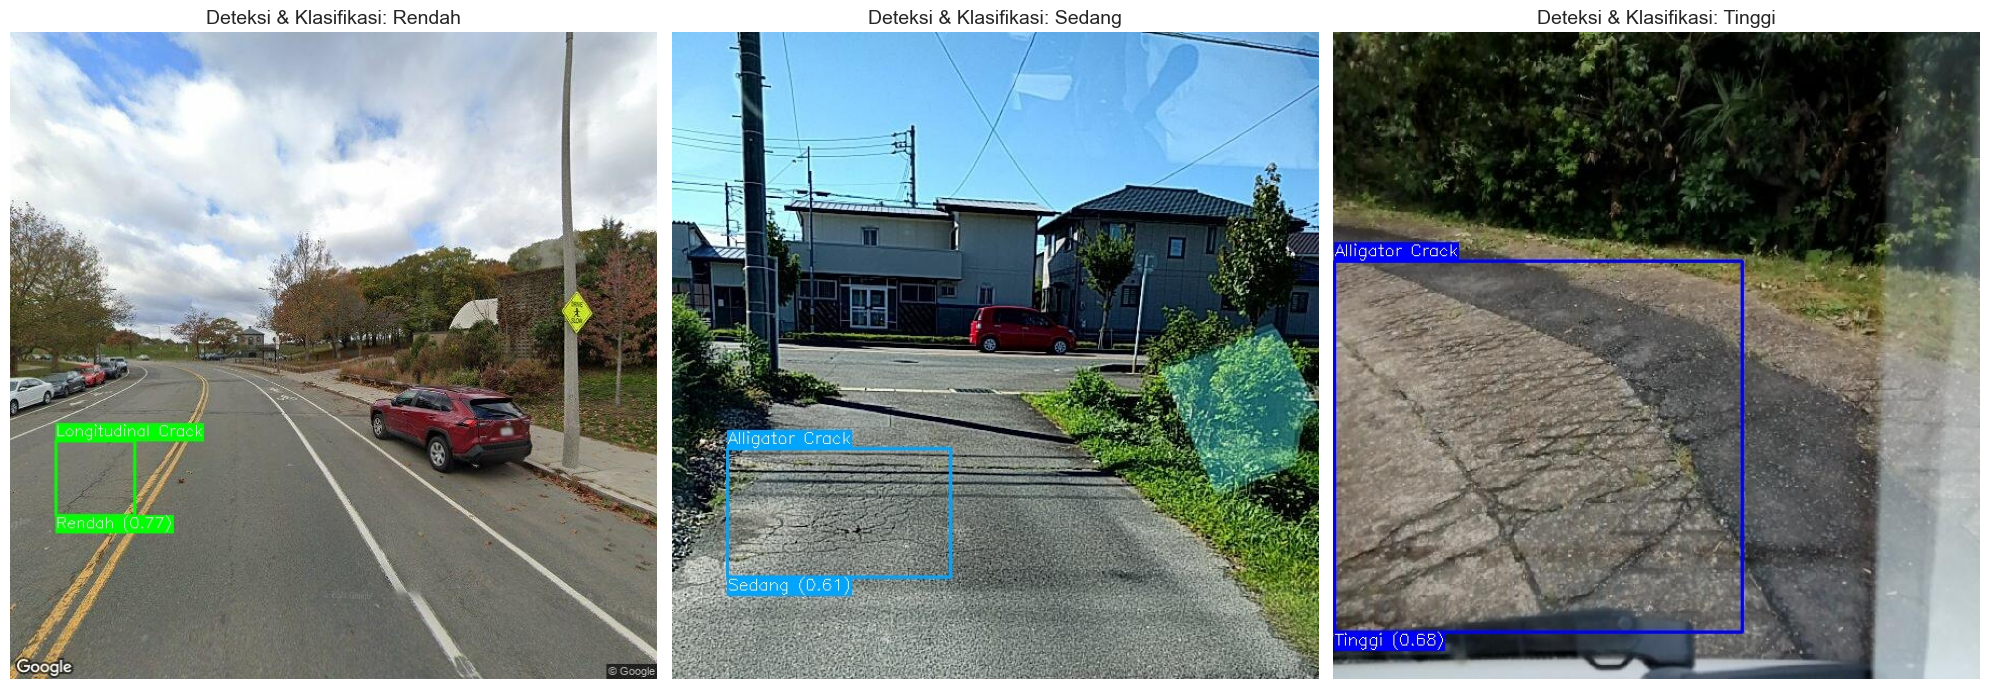

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

print("Memuat hasil inferensi End-to-End...")

target_images = [
    "United_States_001512_Rendah.jpg",
    "Japan_003816_Sedang.jpg",
    "Japan_012313_Tinggi.jpg"
]

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
axes = axes.flatten()

for i, img_name in enumerate(target_images):
    img_path = os.path.join(VISUALIZATIONS_DIR, img_name)

    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].axis('off')

        label = img_name.split('_')[-1].replace('.jpg', '')
        axes[i].set_title(f"Deteksi & Klasifikasi: {label}", fontsize=14, fontweight='bold')
    else:
        # Kalau gambarnya nggak ketemu (misalnya beda nama/folder)
        axes[i].text(0.5, 0.5, f"Gambar tidak ditemukan:\n{img_name}",
                     ha='center', va='center', fontsize=12, color='red')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

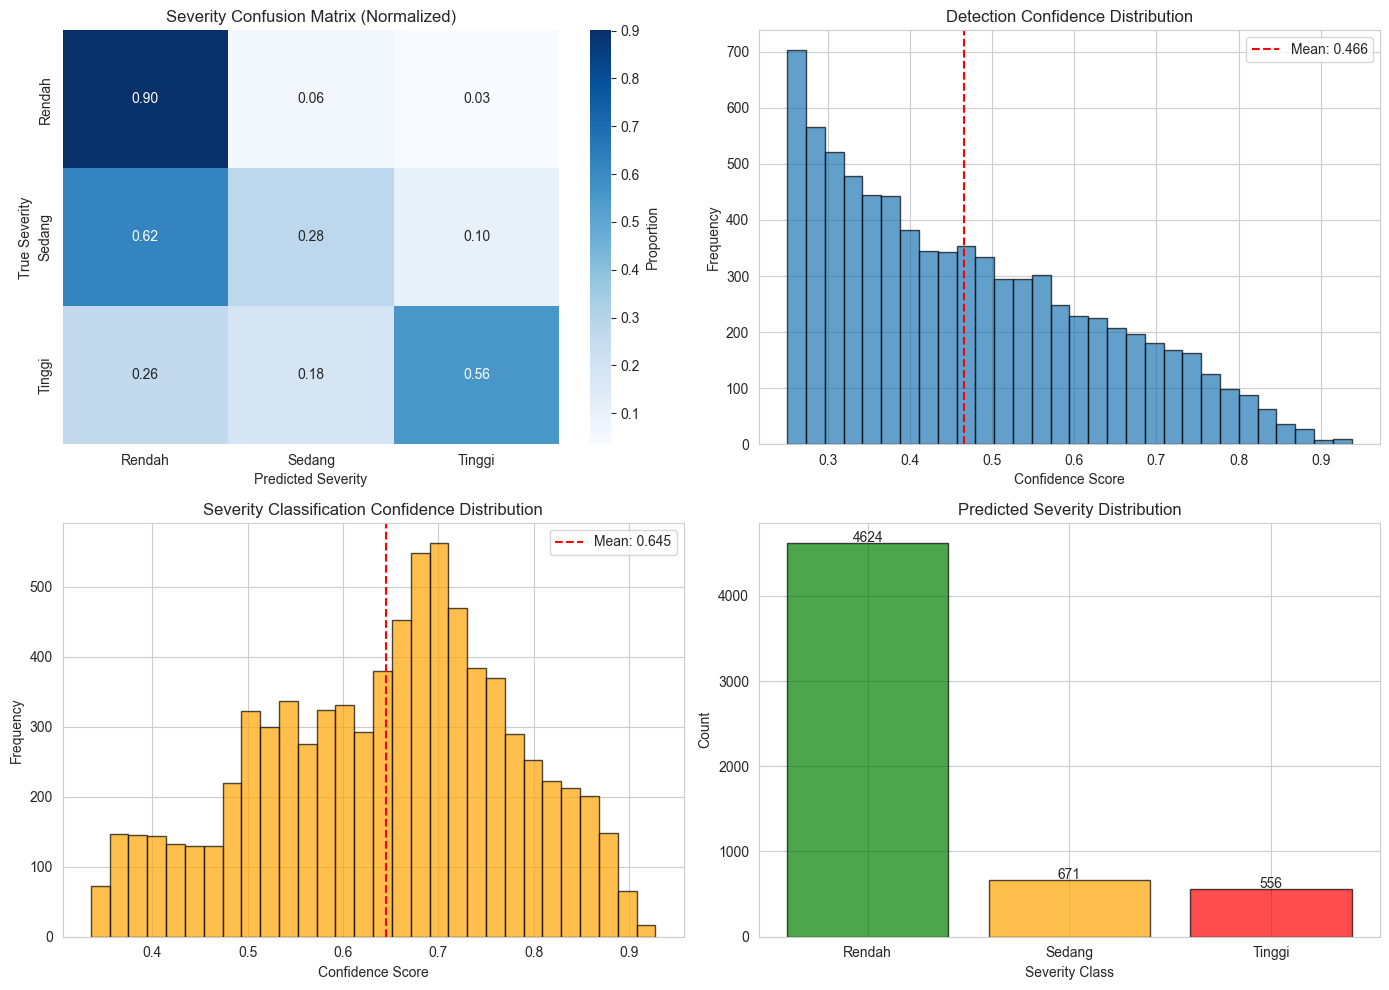


Summary charts saved: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/inference_results/metrics/summary_charts.png


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

fig, axes = plt.subplots(2, 2)

# 1. Confusion Matrix Heatmap
if len(y_true_severity) > 0:
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=list(SEVERITY_CLASSES.values()),
                yticklabels=list(SEVERITY_CLASSES.values()),
                ax=axes[0, 0], cbar_kws={'label': 'Proportion'})
    axes[0, 0].set_title('Severity Confusion Matrix (Normalized)')
    axes[0, 0].set_ylabel('True Severity')
    axes[0, 0].set_xlabel('Predicted Severity')

# 2. Detection confidence distribution
detection_confs = [det['detection_conf'] for r in all_results for det in r['detections']]
axes[0, 1].hist(detection_confs, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Detection Confidence Distribution')
axes[0, 1].set_xlabel('Confidence Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(x=np.mean(detection_confs), color='red', linestyle='--',
                   label=f'Mean: {np.mean(detection_confs):.3f}')
axes[0, 1].legend()

# 3. Severity classification confidence distribution
severity_confs = [det['severity_confidence'] for r in all_results for det in r['detections']]
axes[1, 0].hist(severity_confs, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('Severity Classification Confidence Distribution')
axes[1, 0].set_xlabel('Confidence Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(x=np.mean(severity_confs), color='red', linestyle='--',
                   label=f'Mean: {np.mean(severity_confs):.3f}')
axes[1, 0].legend()

# 4. Severity class distribution (predictions)
if len(y_pred_severity) > 0:
    severity_counts = pd.Series(y_pred_severity).value_counts().sort_index()
    severity_names = [SEVERITY_CLASSES[i] for i in severity_counts.index]

    axes[1, 1].bar(severity_names, severity_counts.values,
                   color=['green', 'orange', 'red'], alpha=0.7, edgecolor='black')
    axes[1, 1].set_title('Predicted Severity Distribution')
    axes[1, 1].set_xlabel('Severity Class')
    axes[1, 1].set_ylabel('Count')

    for i, (name, count) in enumerate(zip(severity_names, severity_counts.values)):
        axes[1, 1].text(i, count + 10, str(count), ha='center', fontweight='bold')

plt.tight_layout()
summary_charts_path = os.path.join(METRICS_DIR, 'summary_charts.png')
plt.savefig(summary_charts_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSummary charts saved: {summary_charts_path}")

In [19]:
import datetime

print("Generating final evaluation report...")

# Compile end-to-end metrics
report = {
    'evaluation_metadata': {
        'timestamp': datetime.datetime.now().isoformat(),
        'test_set_size': len(test_images),
        'images_with_detections': images_with_detections,
        'total_detections': total_detections
    },

    'detection_performance': detection_metrics,

    'severity_classification_performance': severity_metrics if len(y_true_severity) > 0 else None,

    'confidence_statistics': {
        'detection': {
            'mean': float(np.mean(detection_confs)),
            'std': float(np.std(detection_confs)),
            'min': float(np.min(detection_confs)),
            'max': float(np.max(detection_confs))
        },
        'severity': {
            'mean': float(np.mean(severity_confs)),
            'std': float(np.std(severity_confs)),
            'min': float(np.min(severity_confs)),
            'max': float(np.max(severity_confs))
        }
    },

    'sample_visualizations': {
        'total_generated': viz_count,
        'directory': VISUALIZATIONS_DIR
    }
}

# Save report
report_path = os.path.join(METRICS_DIR, 'final_evaluation_report.json')
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)

print(f"\nFinal evaluation report saved: {report_path}")

# Also create human-readable summary
summary_path = os.path.join(METRICS_DIR, 'evaluation_summary.txt')
with open(summary_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("INTEGRATED PIPELINE EVALUATION SUMMARY\n")
    f.write("="*80 + "\n\n")

    f.write(f"Evaluation Date: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Test Set Size: {len(test_images)} images\n")
    f.write(f"Images with Detections: {images_with_detections}\n")
    f.write(f"Total Detections: {total_detections}\n\n")

    f.write("-"*80 + "\n")
    f.write("YOLO DETECTION PERFORMANCE\n")
    f.write("-"*80 + "\n")
    f.write(f"mAP@0.5:          {detection_metrics['mAP@0.5']:.4f}\n")
    f.write(f"mAP@0.5:0.95:     {detection_metrics['mAP@0.5:0.95']:.4f}\n")
    f.write(f"Precision:        {detection_metrics['precision']:.4f}\n")
    f.write(f"Recall:           {detection_metrics['recall']:.4f}\n\n")

    if severity_metrics:
        f.write("-"*80 + "\n")
        f.write("CNN SEVERITY CLASSIFICATION PERFORMANCE\n")
        f.write("-"*80 + "\n")

        for sev_class, sev_name in SEVERITY_CLASSES.items():
            if sev_name in severity_metrics['classification_report']:
                metrics = severity_metrics['classification_report'][sev_name]
                f.write(f"\n{sev_name}:\n")
                f.write(f"  Precision: {metrics['precision']:.4f}\n")
                f.write(f"  Recall:    {metrics['recall']:.4f}\n")
                f.write(f"  F1-Score:  {metrics['f1-score']:.4f}\n")

        f.write(f"\nOverall Accuracy: {severity_metrics['classification_report']['accuracy']:.4f}\n")

    f.write("\n" + "="*80 + "\n")
    f.write("EVALUATION COMPLETE\n")
    f.write("="*80 + "\n")

print(f"Human-readable summary saved: {summary_path}")

Generating final evaluation report...

Final evaluation report saved: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/inference_results/metrics/final_evaluation_report.json
Human-readable summary saved: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/inference_results/metrics/evaluation_summary.txt


In [23]:
print("="*80)
print("INTEGRATED PIPELINE EVALUATION COMPLETE")
print("="*80)

print("\nKey Results:")
print(f"  Test images processed: {len(all_results)}")
print(f"  Total detections: {total_detections}")
print(f"  Detection mAP@0.5: {detection_metrics['mAP@0.5']:.4f}")

if severity_metrics:
    print(f"  Severity accuracy: {severity_metrics['classification_report']['accuracy']:.4f}")
    print(f"\n  Per-class Severity F1-Scores:")
    for sev_name in SEVERITY_CLASSES.values():
        if sev_name in severity_metrics['classification_report']:
            f1 = severity_metrics['classification_report'][sev_name]['f1-score']
            print(f"    {sev_name}: {f1:.4f}")

print("\nOutput Files:")
print(f"  Inference results: {os.path.join(METRICS_DIR, 'inference_results.json')}")
print(f"  Detection metrics: {os.path.join(METRICS_DIR, 'yolo_detection_metrics.json')}")
print(f"  Severity metrics: {os.path.join(METRICS_DIR, 'cnn_severity_metrics.json')}")
print(f"  Final report: {os.path.join(METRICS_DIR, 'final_evaluation_report.json')}")
print(f"  Summary text: {os.path.join(METRICS_DIR, 'evaluation_summary.txt')}")
print(f"  Visualizations: {VISUALIZATIONS_DIR} ({viz_count} images)")
print(f"  Charts: {os.path.join(METRICS_DIR, 'summary_charts.png')}")

print("\n" + "="*80)
print("All evaluation artifacts saved to:")
print(f"  {INFERENCE_RESULTS_DIR}")
print("="*80)

INTEGRATED PIPELINE EVALUATION COMPLETE

Key Results:
  Test images processed: 5757
  Total detections: 7875
  Detection mAP@0.5: 0.5304
  Severity accuracy: 0.7537

  Per-class Severity F1-Scores:
    Rendah: 0.8607
    Sedang: 0.3425
    Tinggi: 0.5466

Output Files:
  Inference results: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/inference_results/metrics/inference_results.json
  Detection metrics: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/inference_results/metrics/yolo_detection_metrics.json
  Severity metrics: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/inference_results/metrics/cnn_severity_metrics.json
  Final report: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/inference_results/metrics/final_evaluation_report.json
  Summary text: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/inference_results/metrics/evaluation_summary.txt
  Visualizations: /content/drive/MyDrive/ipynb-proje